# 数据读取

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
# 中文字体路径
font_path = "/kaggle/input/datasets/rush0high/simhei/SimHei.ttf"
# 注册字体
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

data = {}
name_list = ['customers','sellers','reviews','items','products','geolocation','translation','orders','payments'] 
for f,name in zip(Path(r'/kaggle/input/datasets/rush0high/olist-data').iterdir(), name_list):
    data[name] = pd.read_csv(f)
    

# 基本信息查看

In [2]:
for key,df in data.items():
    print(f'《{key}表的基本信息》')
    df.info()
    if not df[df.duplicated()].empty:
        print(f"《{key}表具有重复值》")
    print('='*100)

《customers表的基本信息》
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
《sellers表的基本信息》
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int6

# 预处理
- 重复值处理
- 缺失值处理
- 字符转时间类型
- 产品种类名称转换

In [3]:
# 处理重复值
geolocation = data['geolocation']
geolocation.drop_duplicates(inplace = True)

#处理缺失值
'''
reviews，products,orders表存在缺失值
1. 保留reviews的缺失状况
2. products表存在产品未分类缺失值和产品描述类信息的缺失
处理：对未分类的产品进行标记，将描述信息填充0值
3. orders表存在支付验证通过时间，货物发送时间，货物到达时间的缺失
处理：根据订单状态的判断，对特定时间缺失的订单打上异常标签
'''
# products缺失值处理
temp = data['products'].copy()
temp['product_category_name'] = temp['product_category_name'].fillna('Unclassified')
temp.iloc[:,2:] = temp.iloc[:,2:].fillna(0)
data['products'] = temp

# orders缺失值处理
temp1 = data['orders'].copy()
condition1 = (
    (temp1['order_status'] == 'delivered') &\
    (temp1['order_delivered_customer_date'].isna())
)
condition2 = (
    (~temp1['order_status'].isin(['created','canceled','unavailable']))  &\
    (temp1['order_approved_at'].isna())
)
condition3 = (
    (temp1['order_status'].isin(['delivered','shipped'])) &\
    (temp1['order_approved_at'].isna())
)
temp1['is_anomaly'] = (condition1) | (condition2) | (condition3) 
data['orders'] = temp1

# 转换字符为时间类型
'''
reviews表和orders表存在时间信息
'''
# reviews表
temp2 = data['reviews']
for col in temp2.iloc[:,-2:].columns:
    temp2[col] = pd.to_datetime(temp2[col])

# orders表
temp3 = data['orders']
for col in temp3.iloc[:,3:8].columns:
    temp3[col] = pd.to_datetime(temp3[col])

# 产品类型名称转换
'''
葡萄牙语转换为英语
'''
temp4 = pd.merge(
    data['products'],data['translation'],
    left_on = 'product_category_name',right_on = 'product_category_name',
    how = 'left'
)

temp4['product_category_name_english'] = temp4['product_category_name_english'].fillna('unclassified')
temp4 = temp4.drop(columns=['product_category_name'])
data['products'] = temp4

# 数据探索性分析

In [4]:
# 将items表和orders表进行连接和筛选，为后续销售信息进行统计和分析做好准备
orders_clean = pd.merge(data['items'],data['orders'],left_on = 'order_id',right_on = 'order_id',how ='left')
orders_clean = orders_clean[(
    (orders_clean['price'] > 0) &\
    (orders_clean['order_status'] == 'delivered')
)]
# 整体性统计（销售额，销售量，平均订单额）
total_revenue = sum(orders_clean['price'])
orders_count = orders_clean['order_id'].nunique()
avg_orders = orders_clean.groupby('order_id')['price'].sum().mean()
print(f'销售总额:{total_revenue:,}\n订单数:{orders_count:,}\n平均订单额:{round(avg_orders,2)}')

销售总额:13,221,498.11
订单数:96,478
平均订单额:137.04


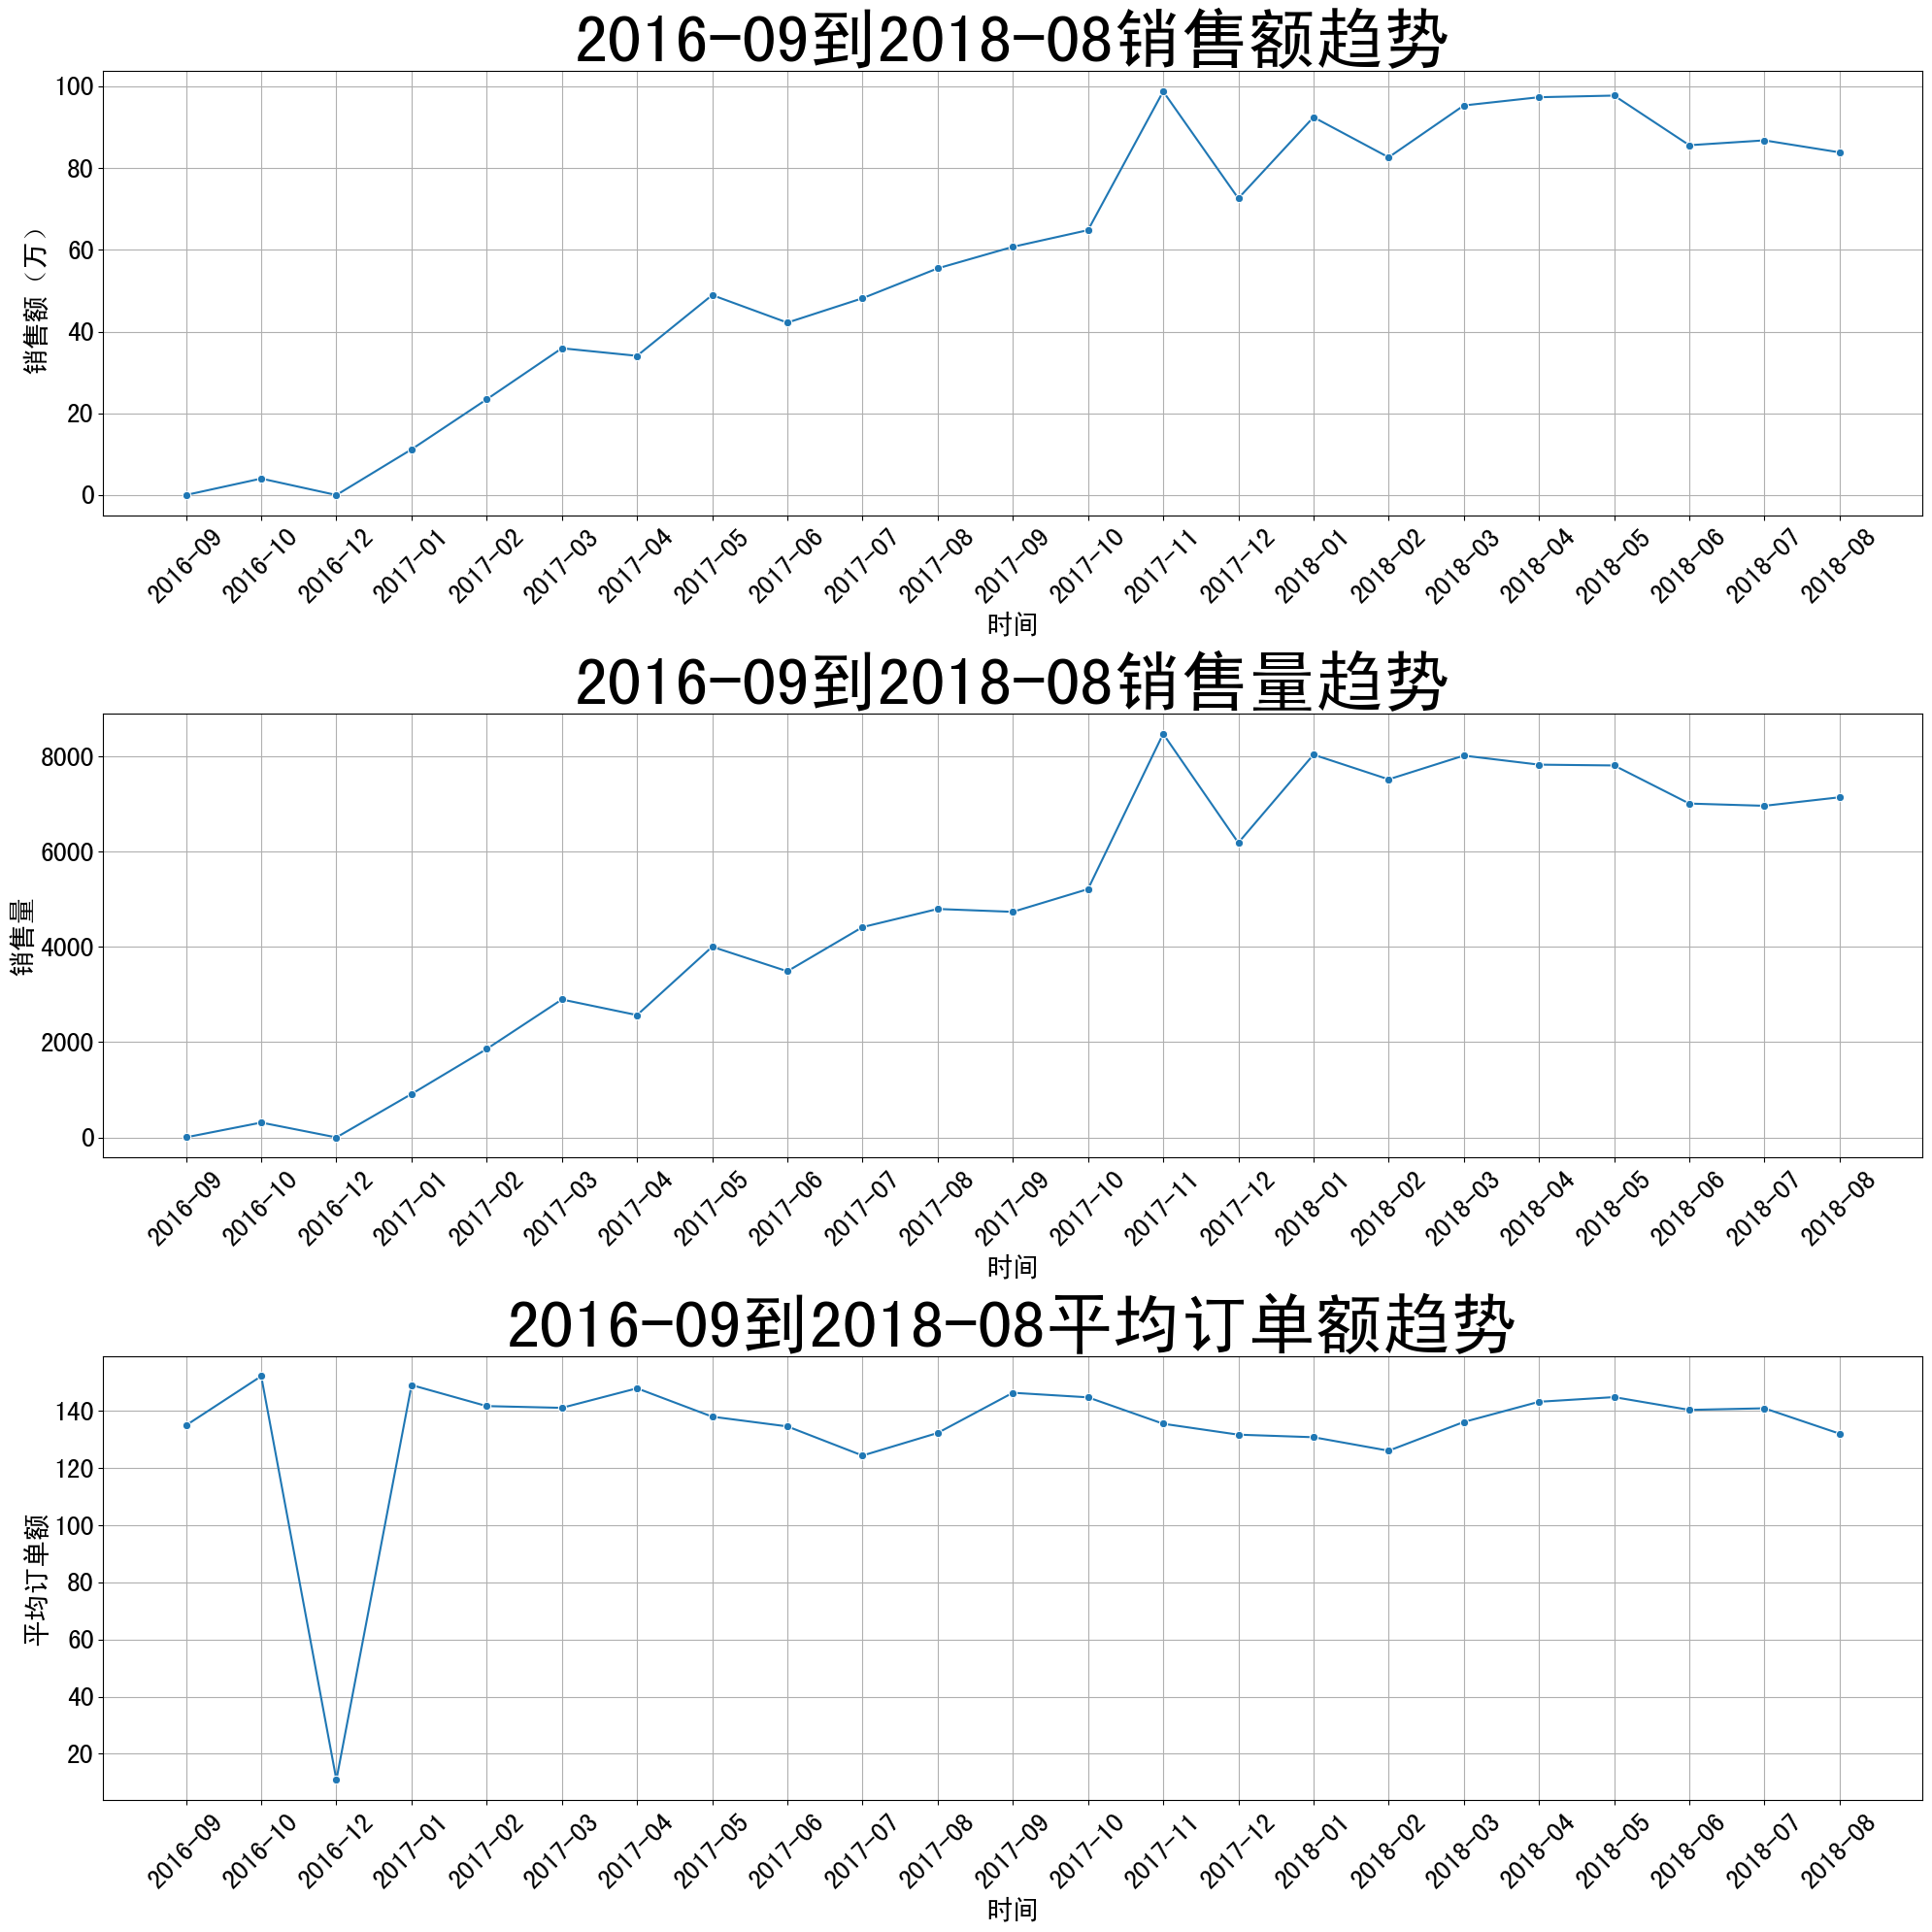

In [5]:
temp = orders_clean.copy()
temp['time'] = temp['order_purchase_timestamp'].dt.to_period("M").astype('str')
# 按月份统计（销售额，销售量，平均订单额）
month_revenue = temp.groupby('time')['price'].sum()
month_orders_count = temp.groupby('time').size()
month_avg_orders = temp.groupby(['order_id','time'])['price'].sum().groupby('time').mean()
# 销售额
fig,ax = plt.subplots(3,1,figsize = (20,20))
sns.lineplot(x = month_revenue.index ,y = month_revenue.values/10000,ax = ax[0],marker = 'o')
ax[0].set_ylabel("销售额（万）",fontsize = 20)
ax[0].set_yticks(range(0,101,20))
ax[0].set_title('2016-09到2018-08销售额趋势',fontsize = 50)
# 销售量
sns.lineplot(x = month_orders_count.index,y = month_orders_count.values,ax = ax[1],marker = 'o')
ax[1].set_ylabel("销售量",fontsize = 20)
ax[1].set_title('2016-09到2018-08销售量趋势',fontsize = 50)
# 平均订单额
sns.lineplot(x = month_avg_orders.index, y = month_avg_orders.values,ax = ax[2],marker = 'o')
ax[2].set_ylabel("平均订单额",fontsize = 20)
ax[2].set_title('2016-09到2018-08平均订单额趋势',fontsize = 50)

for i in ax.flat:
    i.set_xlabel("时间",fontsize = 20)
    i.tick_params(axis = "x",rotation = 45,labelsize = 20)
    i.tick_params(axis = "y",labelsize = 20)
    i.grid()
    
plt.tight_layout()
plt.show()

# print(f'销售额的三个峰值{month_revenue.nlargest(3)}')
# print(f'销售额的三个峰值{month_orders_count.nlargest(3)}')

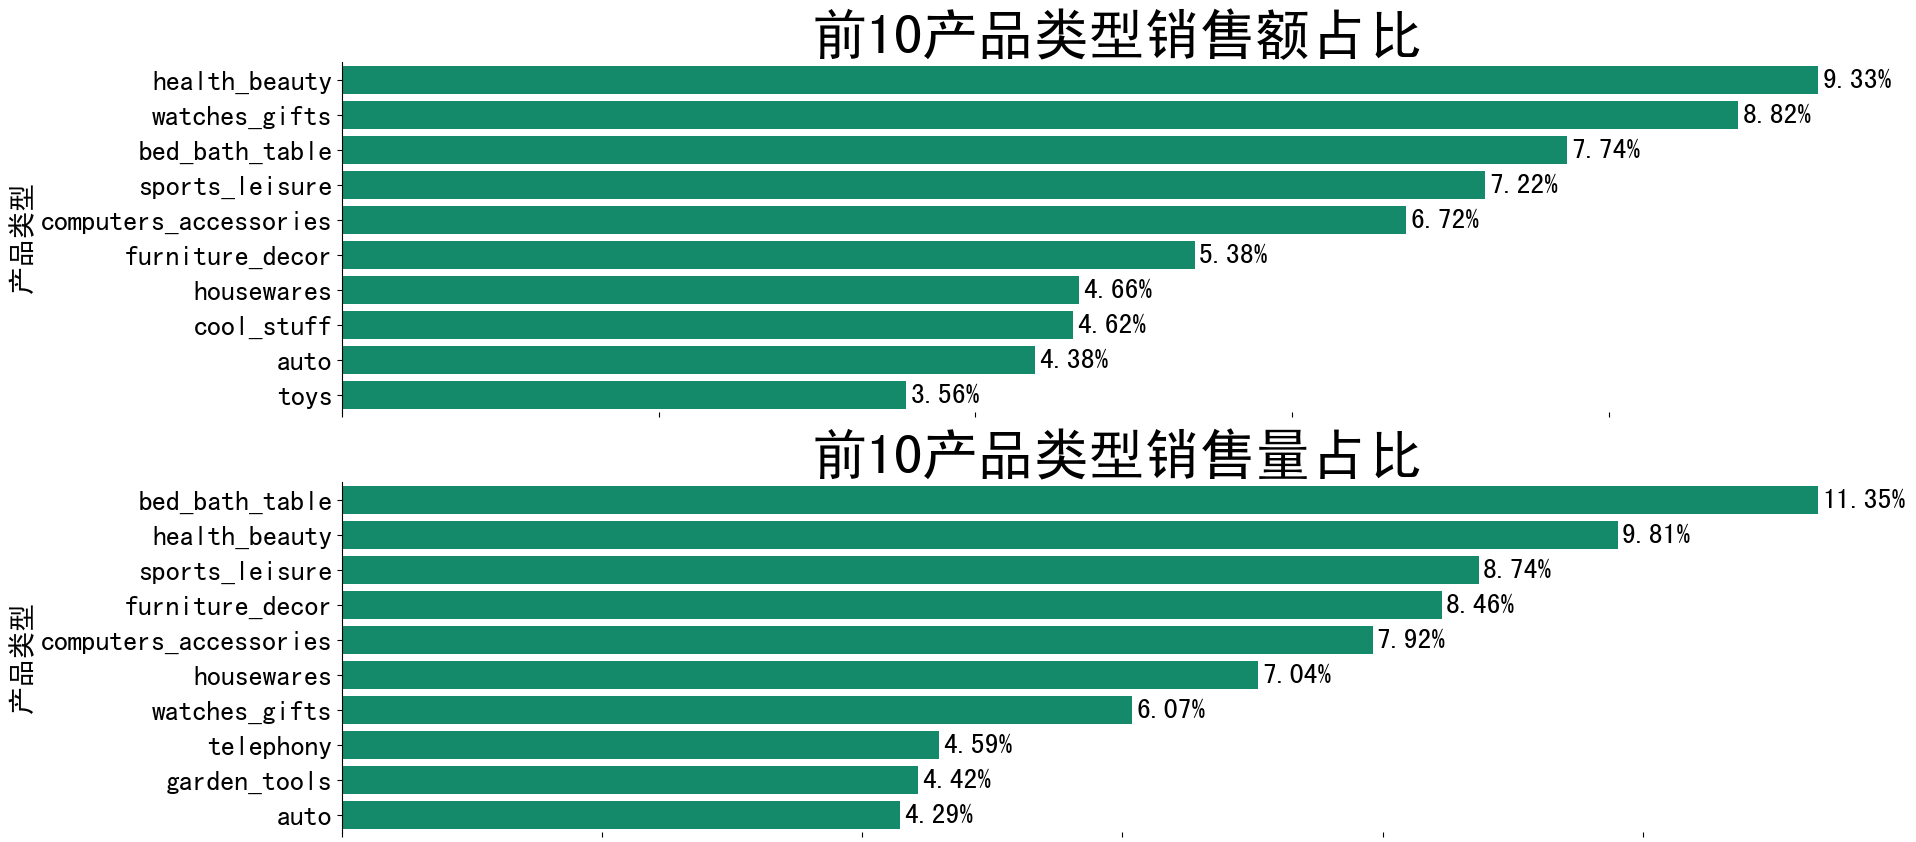

In [6]:
# 按商品类型进行统计
temp = pd.merge(orders_clean,data['products'],left_on = 'product_id',right_on = 'product_id',how = 'left')\
        .groupby('product_category_name_english')['price'].sum()\
        .sort_values(ascending = False).head(10)
temp1 = pd.merge(orders_clean,data['products'],left_on = 'product_id',right_on = 'product_id',how = 'left')\
        ['product_category_name_english'].value_counts()\
        .sort_values(ascending = False).head(10)

fig,ax = plt.subplots(2,1,figsize = (20,10))
# 销售额
sns.barplot(y = temp.index,x = (temp.values / total_revenue) * 100,ax = ax[0],color = "#009E73")
ax[0].set_ylabel('产品类型',fontsize = 20)
ax[0].tick_params(axis = 'y', labelsize=20)
ax[0].tick_params(axis='x', labelbottom=False) 

ax[0].bar_label(ax[0].containers[0], fmt = '%.2f%%', padding = 3, fontsize = 20)

ax[0].spines["bottom"].set_visible(False)
ax[0].spines["right"].set_visible(False)
ax[0].spines["top"].set_visible(False)

ax[0].set_title("前10产品类型销售额占比", fontsize=40, weight="bold")
# 销售量
sns.barplot(y = temp1.index,x = (temp1.values / orders_count) * 100,ax = ax[1],color = "#009E73")
ax[1].set_ylabel('产品类型',fontsize = 20)
ax[1].tick_params(axis = 'y', labelsize=20)
ax[1].tick_params(axis='x', labelbottom=False) 

ax[1].bar_label(ax[1].containers[0], fmt = '%.2f%%', padding = 3, fontsize = 20)

ax[1].spines["bottom"].set_visible(False)
ax[1].spines["right"].set_visible(False)
ax[1].spines["top"].set_visible(False)

ax[1].set_title("前10产品类型销售量占比", fontsize=40, weight="bold")

plt.show()

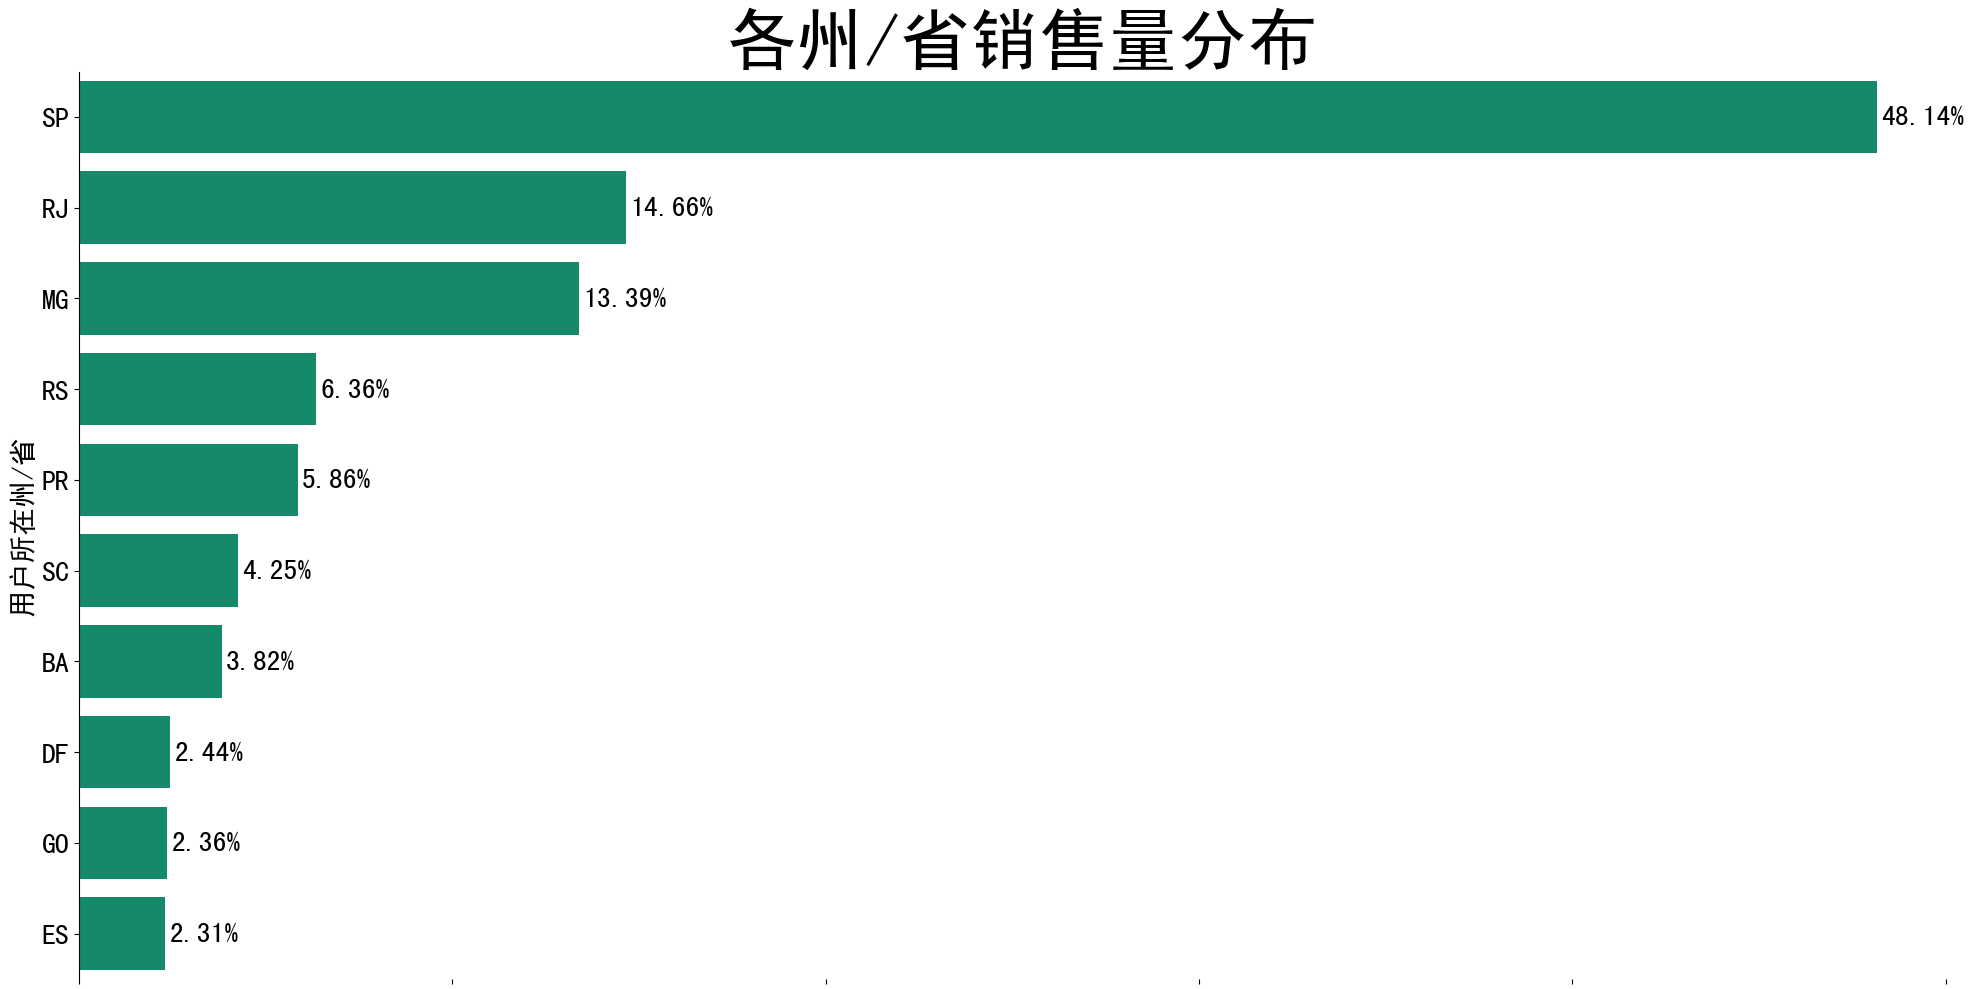

In [7]:
# 按地区进行统计
temp = pd.merge(orders_clean,data['customers'],left_on = 'customer_id',right_on = 'customer_id',how = 'left')\
         ['customer_state'].value_counts().head(10)

fig, ax = plt.subplots(figsize = (20,10))
sns.barplot(y = temp.index, x = (temp.values/orders_count)*100,ax = ax,color = "#009E73")
ax.set_ylabel('用户所在州/省',fontsize = 20)
ax.tick_params(axis = 'y',labelsize = 20)
ax.tick_params(axis = 'x',labelbottom = False)
ax.bar_label(ax.containers[0], fmt = '%.2f%%',padding = 3, fontsize = 20)

ax.spines["bottom"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.set_title("各州/省销售量分布",fontsize = 50,weight="bold")
plt.tight_layout()
plt.show()

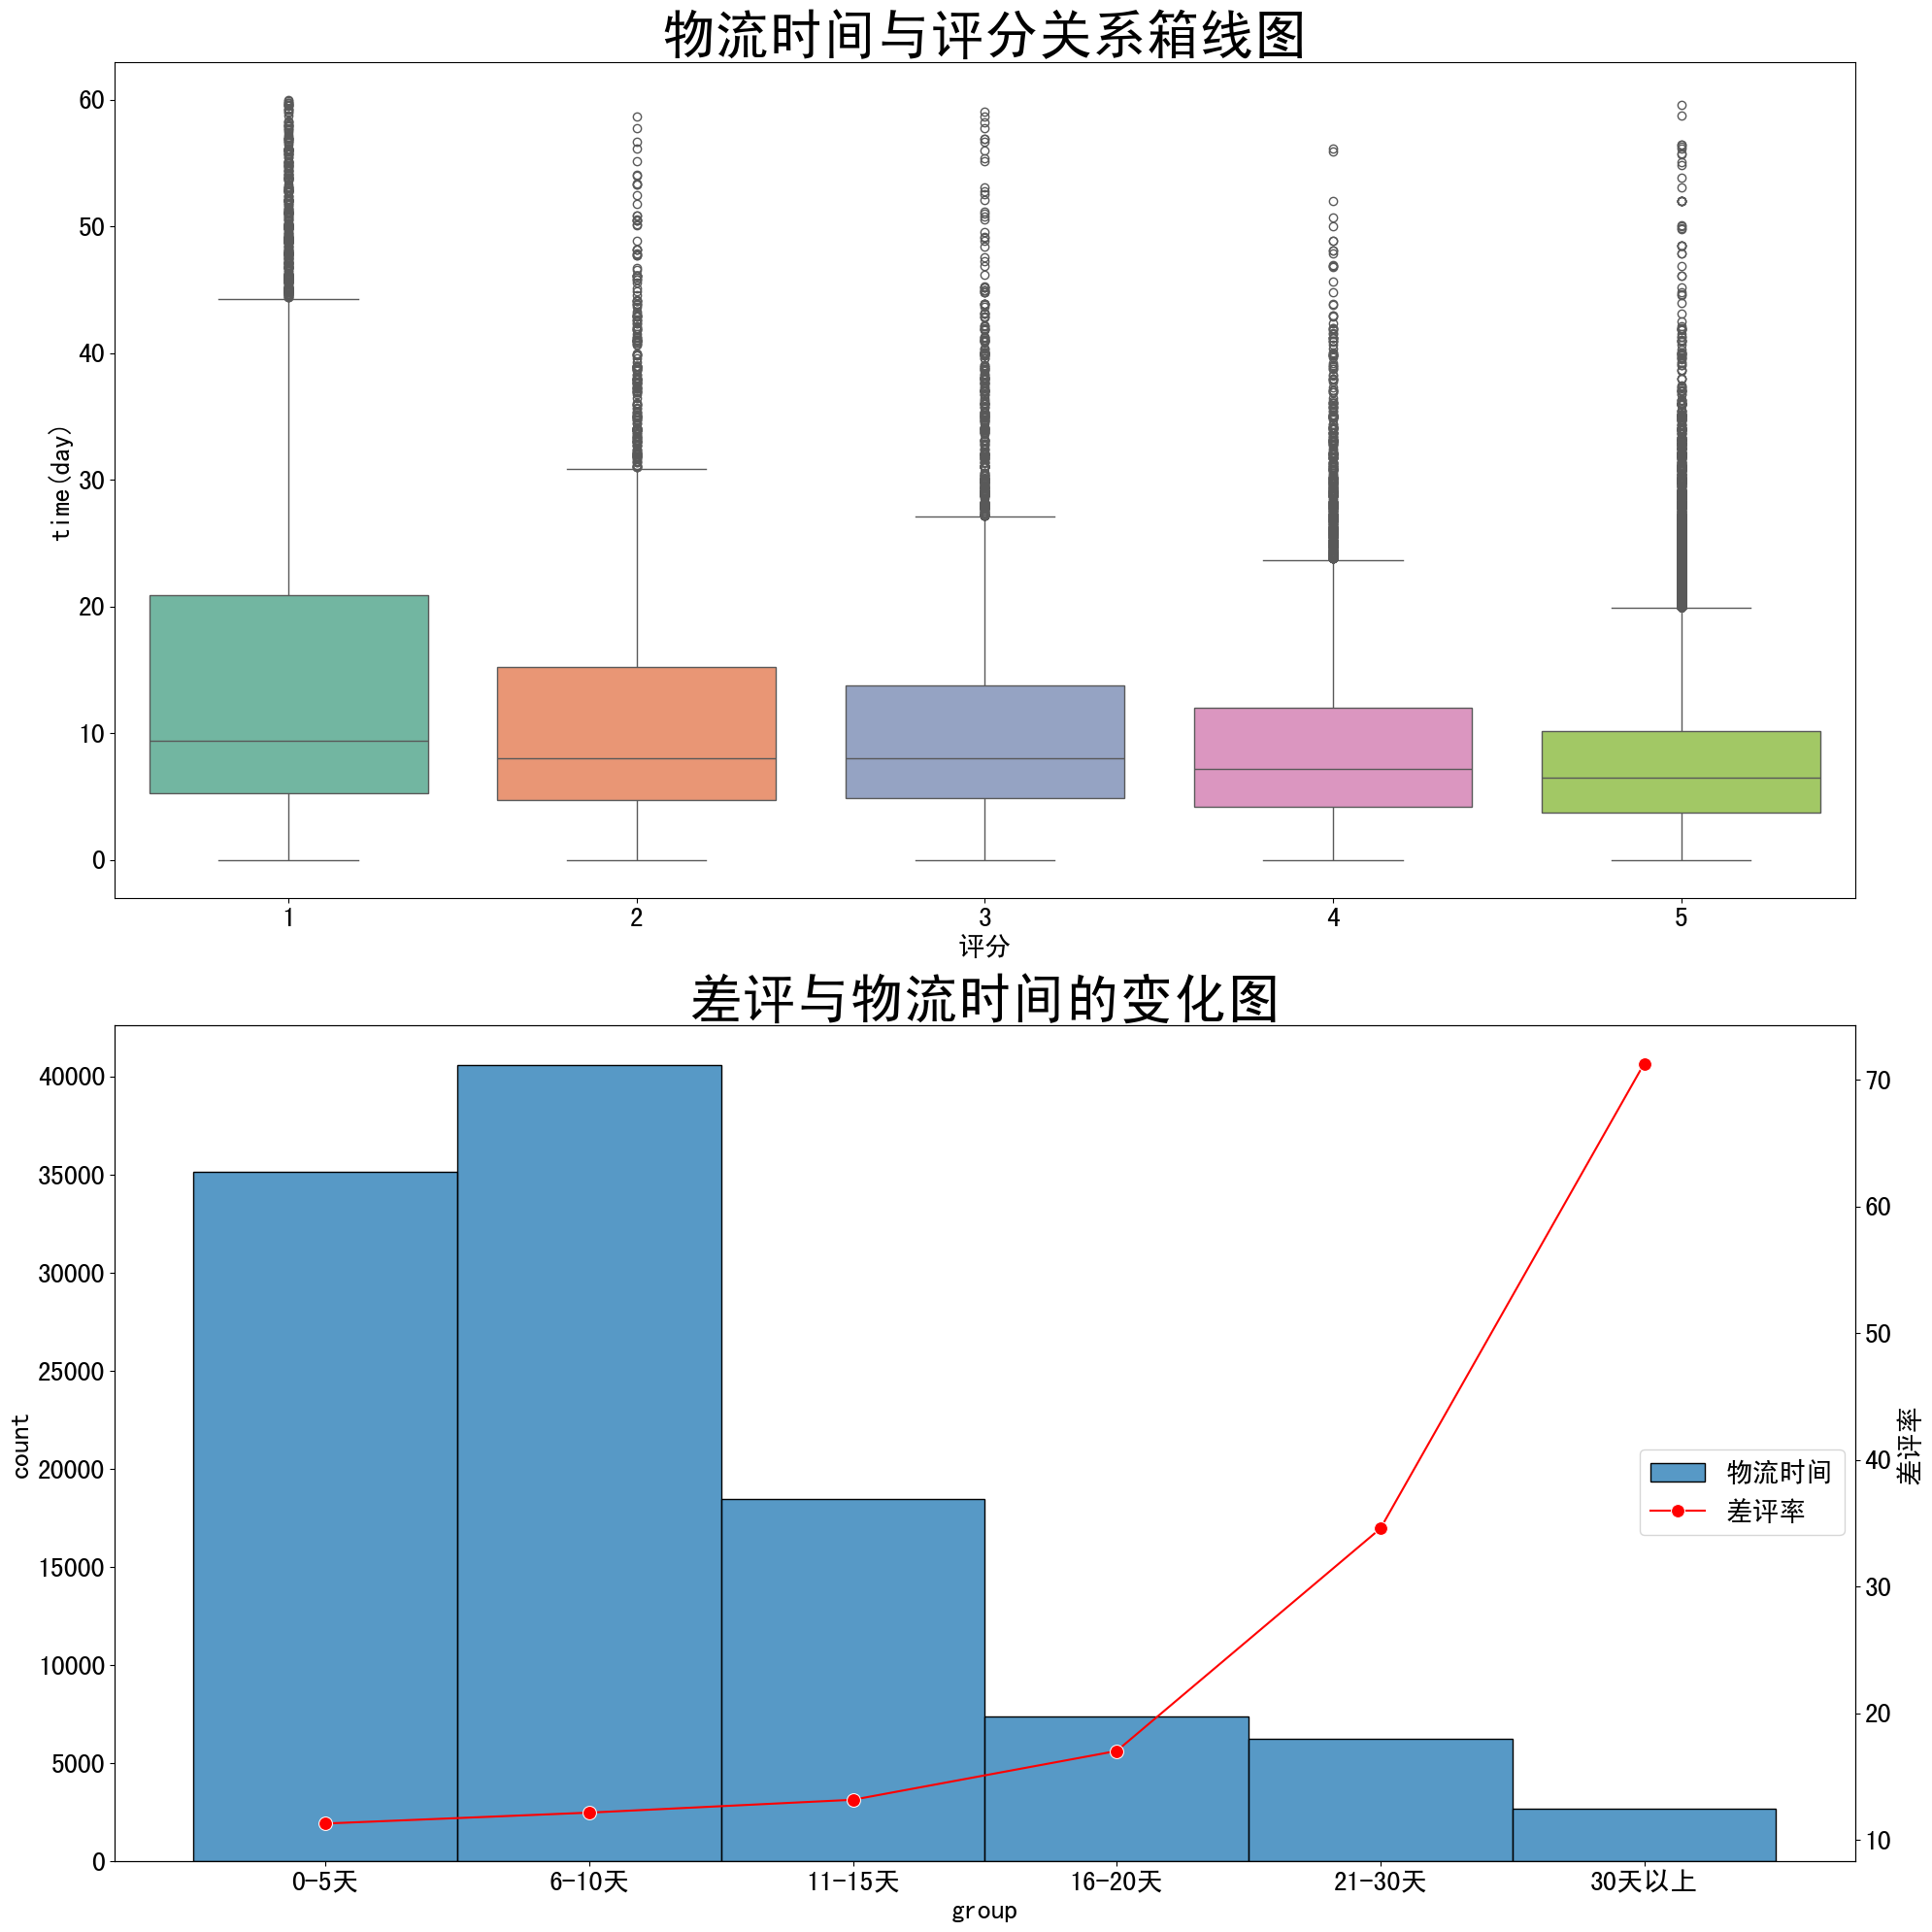

In [8]:
# 分析物流与评分关系
temp = orders_clean.copy()
temp['logistics_time'] = temp['order_delivered_customer_date'] - temp['order_delivered_carrier_date']
temp1 = pd.merge(temp,data['reviews'],left_on = 'order_id',right_on = 'order_id',how = 'left')
temp1 = temp1[['logistics_time','review_score']]
temp1['time'] = round(temp1['logistics_time'].dt.total_seconds()/(3600*24),1)
temp2 = temp1[(temp1['time'] <= 60) & (temp1['time'] >= 0)]

temp3 = temp2.copy()
bins = [0, 5, 10, 15, 20, 30, 60]
labels = ['0-5天','6-10天','11-15天','16-20天','21-30天','30天以上']
temp3['group'] = pd.cut(temp3['time'],bins=bins, labels=labels)
temp4 = temp3.groupby('group', observed=True).\
                agg(差评率=('review_score',lambda x: (x<=2).sum()/len(x)*100))

fig, ax = plt.subplots(2,1,figsize = (20,20))
sns.boxplot(data=temp2,x='review_score',y = 'time',\
            hue='review_score',palette = 'Set2',legend = False,ax = ax[0])
ax[0].set_title('物流时间与评分关系箱线图',fontsize = 40)
ax[0].set_ylabel('time(day)',fontsize = 20)
ax[0].set_xlabel('评分',fontsize = 20)
ax[0].tick_params(axis = 'both',labelsize = 20)

ax2 = ax[1].twinx()
sns.histplot(temp3 ,x = 'group',ax = ax[1],bins=12,label = '物流时间')
sns.lineplot(temp4, x = 'group',y = '差评率',ax = ax2,marker ='o',markersize = 10,color = 'red',label = '差评率')
ax[1].set_title('差评与物流时间的变化图',fontsize = 40)
ax[1].set_xlabel('group',fontsize = 20)
ax[1].set_ylabel('count',fontsize = 20)
ax[1].tick_params(axis = 'both',labelsize = 20)
ax2.set_ylabel('差评率',fontsize = 20)
ax2.tick_params(axis='y',labelsize = 20)

fig.legend(loc='lower left',fontsize = 20, bbox_to_anchor=(0.84, 0.2))
ax[1].legend().set_visible(False)
ax2.legend().set_visible(False)


plt.tight_layout()
plt.show()

# rfm用户分层

In [9]:
# rfm数据标记
rfm = pd.DataFrame()
temp = orders_clean
rfm['r'] = (temp['order_purchase_timestamp'].max() + pd.Timedelta(days=1)- temp.groupby('customer_id')['order_purchase_timestamp'].max()).dt.days
rfm['f'] = temp['customer_id'].value_counts().values
rfm['m'] = temp.groupby('customer_id')['price'].sum().values

rfm['r_mark'] = pd.qcut(rfm['r'],q = 5,labels=[5,4,3,2,1])
rfm['f_mark'] = pd.qcut(rfm['f'].rank(method = 'first'),q = 5,labels=[1,2,3,4,5])
rfm['m_mark'] = pd.qcut(rfm['m'],q = 5,labels=[1,2,3,4,5])

def segment(row):
    r,f,m = row['r_mark'].astype('int'),row['f_mark'].astype('int'),row['m_mark'].astype('int')
    if r >= 4 and f >= 4 and m >= 4:
        return '高价值客户'
    if r >= 4 and f >= 3 and m >= 3:
        return '重要发展客户'
    if r >= 4 and f <= 2:
        return '新客户'
    if r <= 2 and f >= 3:
        return '流失高频客户'
    if r <= 2 and m >= 3:
        return '流失高价值客户'
    else:
        return '普通客户'

rfm['用户分层'] = rfm.apply(segment,axis = 1)

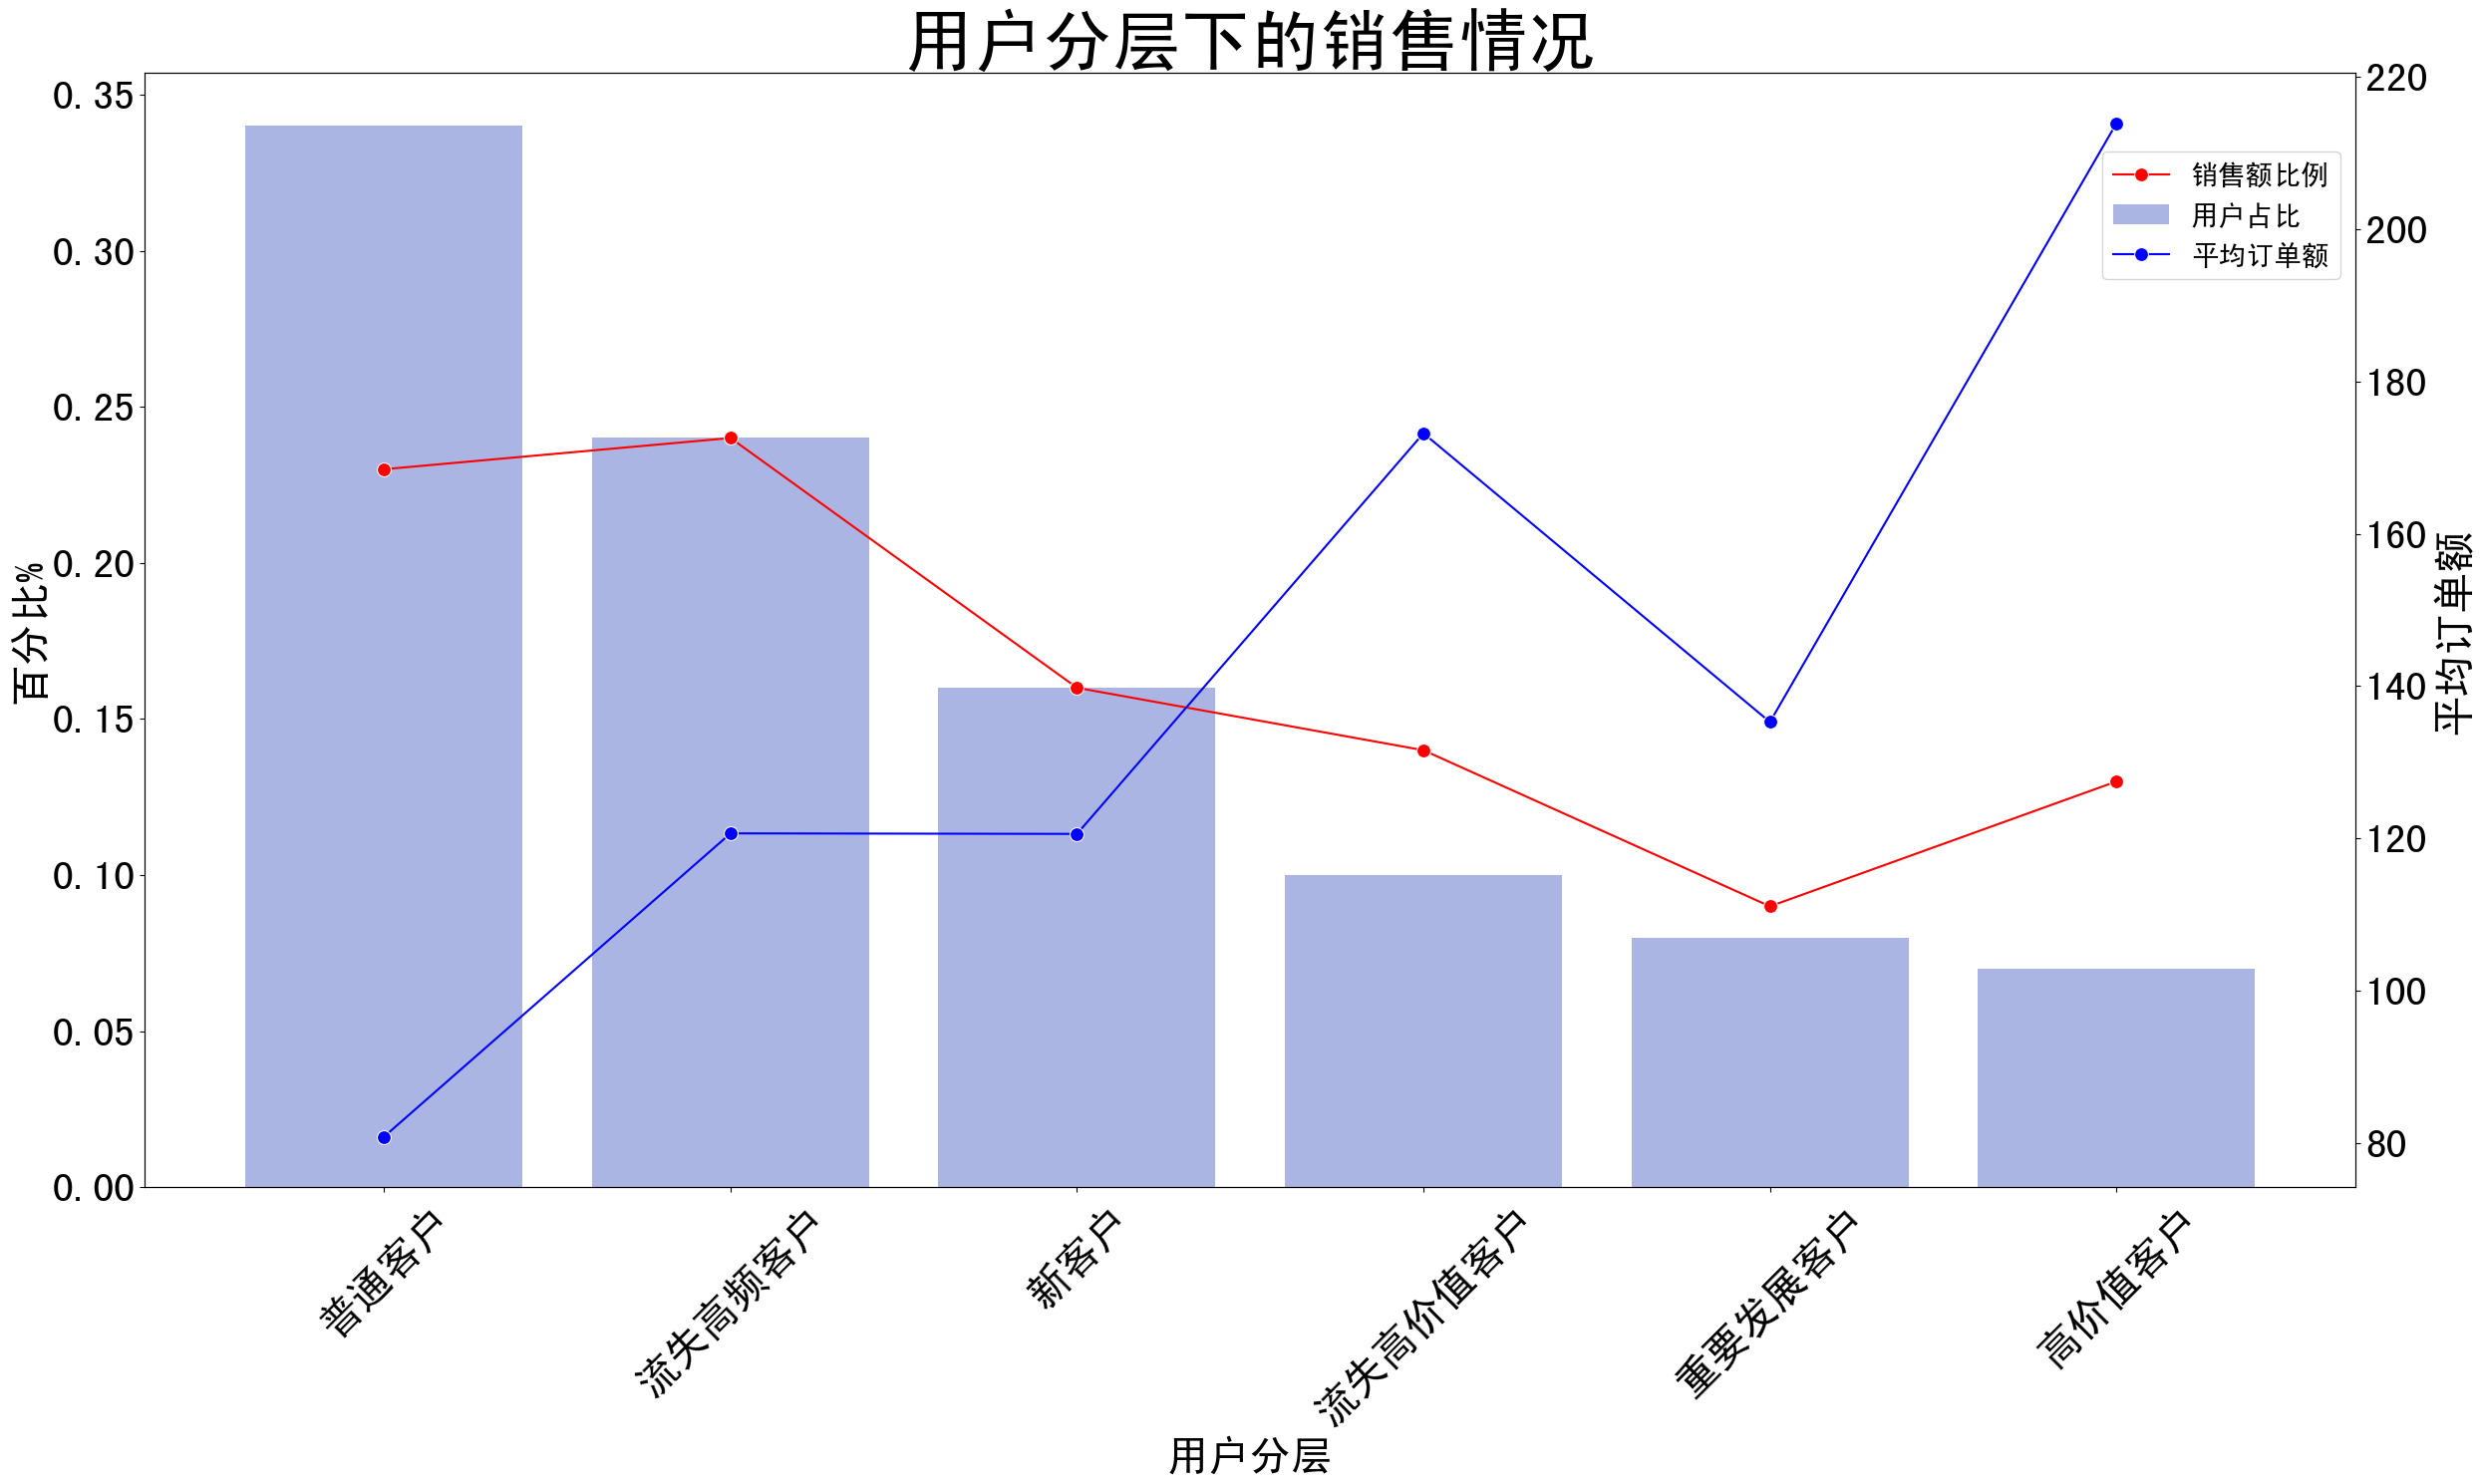

高价值用户与普通用户之间平均订单额的比值为 2.65


In [10]:
# rfm分析
temp = pd.merge(rfm,orders_clean,left_on = 'customer_id',right_on = 'customer_id',how = 'left')
temp1 = temp['用户分层'].value_counts()
temp2 = round(temp1 / temp1.sum(),2)
temp3 = round(temp.groupby('用户分层')['price'].sum() / total_revenue,2).rename('销售额')
temp4 = round(temp.groupby('用户分层')['price'].sum() / temp1,2).rename('平均订单额')
temp5 = pd.concat([temp2, temp3, temp4], axis=1)

fig,ax = plt.subplots(figsize = (25,15))
# 用户分层人数分布
sns.barplot(x =temp5.index,y = temp5['count'],ax = ax,color='#a1afed',label='用户占比')
# 不同用户分层的销售额比例
sns.lineplot(x = temp5.index,y=temp5['销售额'], ax = ax,color = 'red',\
             marker = 'o',markersize = 10,label='销售额比例')
ax.set_ylabel('百分比%',fontsize = 30)
ax.set_xlabel('用户分层',fontsize = 30)
ax.tick_params(axis = "x",rotation = 45,labelsize = 30)
ax.tick_params(axis = "y",labelsize = 30)
ax.set_title('用户分层下的销售情况',fontsize = 50)
ax.legend().set_visible(False)

ax2 = ax.twinx()
# 不同用户分层的平均订单额
sns.lineplot(x = temp5.index,y =temp5['平均订单额'],color = 'blue',ax = ax2,\
             marker='o',markersize=10,label='平均订单额')
ax2.set_ylabel('平均订单额',fontsize = 30)
ax2.set_xlabel('用户分类',fontsize = 30)
ax2.tick_params(axis = "x",rotation = 45,labelsize = 30)
ax2.tick_params(axis = "y",labelsize = 30)
ax2.legend().set_visible(False)

fig.legend(loc='lower left',fontsize = 20, bbox_to_anchor=(0.84, 0.8))
plt.tight_layout()
plt.show()

t = temp4.sort_values(ascending = False)
rate = round(t.head(1).mean()/t.tail(1).mean(),2)
print(f"高价值用户与普通用户之间平均订单额的比值为 {rate}")

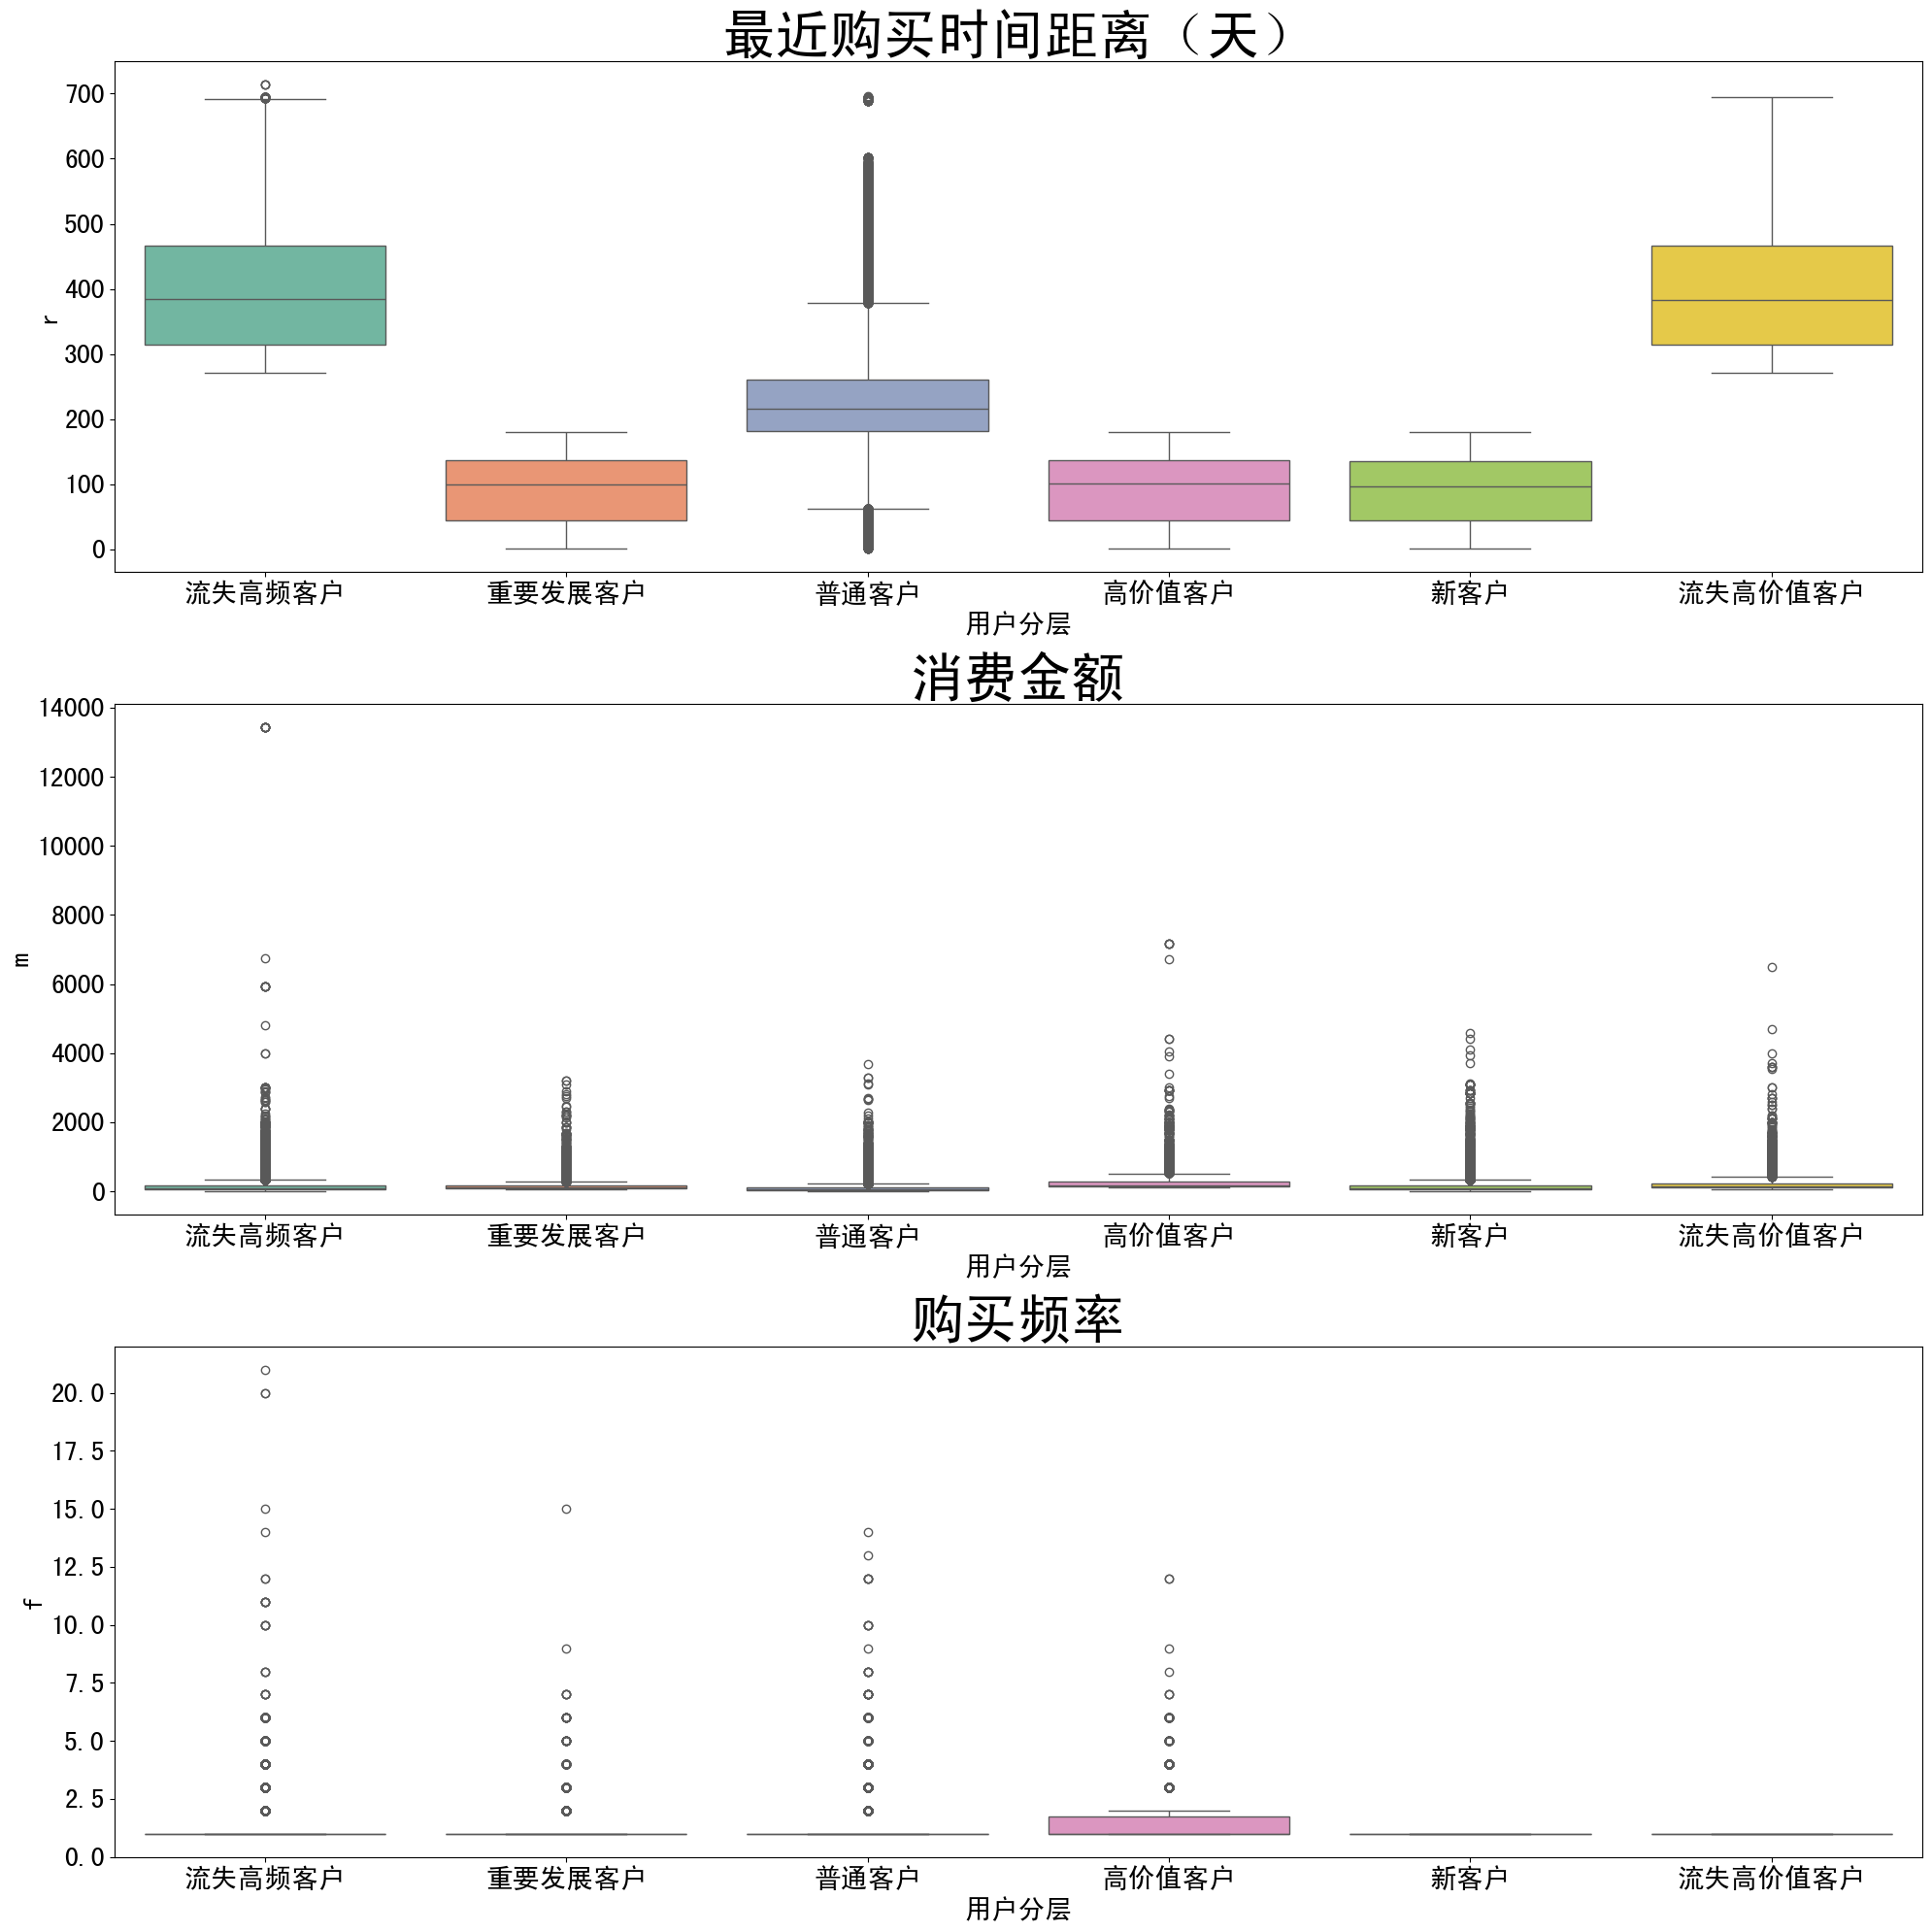

In [11]:
# 查看不同用户分层下的具体rfm情况
fig,ax = plt.subplots(3,1,figsize=(20,20))
cols = ['r','m','f'] 
titles = ['最近购买时间距离（天）','消费金额','购买频率']
for ax,y ,title in zip(ax.flat,cols,titles):
    sns.boxplot(data=temp,x='用户分层',y = y,hue='用户分层',palette = 'Set2',legend = False,ax = ax)
    ax.set_ylabel(y,fontsize = 20)
    ax.set_xlabel("用户分层",fontsize = 20)
    ax.tick_params(axis='both',labelsize = 20)
    
    ax.set_title(title,fontsize = 40)
plt.tight_layout()
plt.show()
